# Restaurant Review Sentiment Analysis

In [1]:
# Data Visual
from wordcloud import WordCloud
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

#Transformation
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Model Logistic Regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import contractions



# Classification Report
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

# Crawl Data
import requests
from bs4 import BeautifulSoup
import time

import nltk
from nltk.stem.porter import PorterStemmer


import pandas as pd
import re
import numpy as np

### Import dataset into data

In [ ]:
# Load the TSV file into a pandas DataFrame
data = pd.read_csv('Restaurant_Reviews.tsv', sep='\t')

# Print the first few rows of the DataFrame
print(data.head())

                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1


In [3]:
# Find duplicate rows based on all columns
duplicate_rows = data[data.duplicated()]

# Display the duplicate rows
print(duplicate_rows)

#Lets check total duplicate values in the data
data.duplicated().sum()

# Check for the lengths of the Review texts
data['Length'] = data['Review'].apply(len)
data.head()

                                Review  Liked
814                 I love this place.      1
816             The food was terrible.      0
843                   I won't be back.      0
846  I would not recommend this place.      0


,Review,Liked,Length
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59


In [4]:
#Missing data check
def missing_value_report(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent = (data.isnull().sum()/data.isnull().count()).sort_values(ascending=False)
    missing_data = pd.concat([total, percent * 100], axis=1, keys=['Total', 'Percent(%)'])
    return missing_data.head(5)

#Checking missing values accross columns in the dataset
missing_value_report(data)

,Total,Percent(%)
Review,0,0.0
Liked,0,0.0
Length,0,0.0


### Preprocessing data

In [5]:
# Function to clean the review text
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    text = contractions.fix(text)

    # Remove Negation
    text = re.sub(r'not\s+(\w+)\b', r'not_\1', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)


    return text
# Apply the cleaning function to the review column
data['Review'] = data['Review'].apply(clean_text)

data = data.drop_duplicates()
data = data.dropna()

# Print the cleaned dataset
print(data.head())

                                              Review  Liked  Length
0                               wow loved this place      1      24
1                                  crust is not_good      0      18
2           not_tasty and the texture was just nasty      0      41
3  stopped by during the late may bank holiday of...      1      87
4  the selection on the menu was great and so wer...      1      59


## Data Visualization

In [6]:
# Describing the reviews after grouping 
data.groupby('Liked').describe()

Length                                                      
       count       mean        std   min   25%   50%    75%    max
Liked                                                             
0      496.0  61.062500  34.179120  11.0  33.0  53.0  84.25  149.0
1      499.0  55.955912  30.202032  11.0  33.0  50.0  73.50  148.0

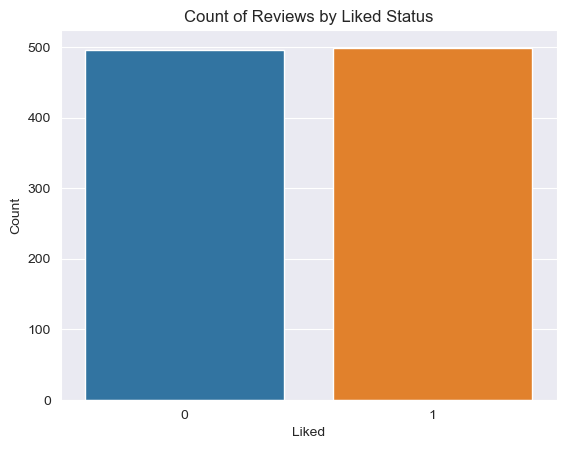

In [7]:
# Set the style of the plot
sns.set_style('darkgrid')

# Create a count plot of the "Liked" column
sns.countplot(x='Liked', data=data)

# Set the title of the plot
plt.title('Count of Reviews by Liked Status')

# Set the label for the x-axis
plt.xlabel('Liked')

# Set the label for the y-axis
plt.ylabel('Count')

# Show the plot
plt.show()

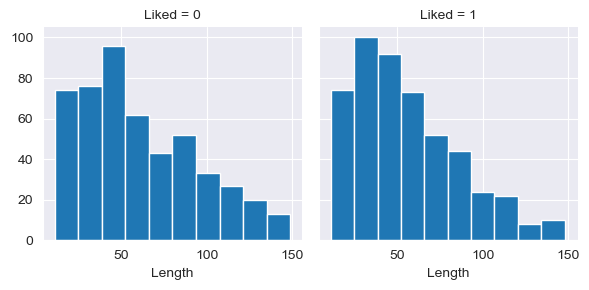

In [8]:
# Create a FacetGrid object with 'Liked' as the column to be used for separating the data
# FacetGrid is a grid of subplots that displays the same relationship between different subsets of your data.
g = sns.FacetGrid(data, col='Liked')

# Use the FacetGrid object to plot a histogram of the 'Length' column for each value of 'Liked'
g.map(plt.hist, 'Length');

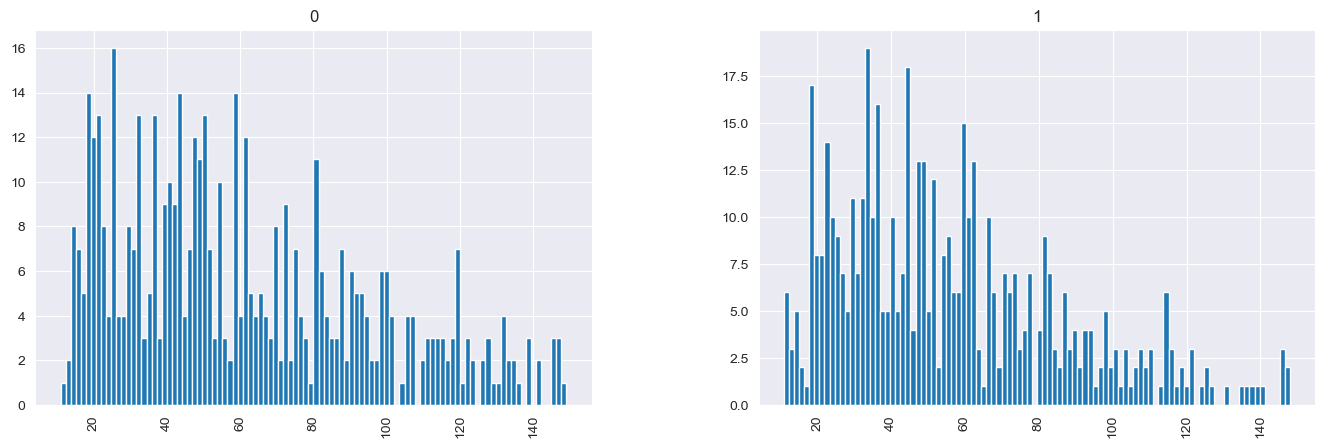

In [9]:
# Comparing length of messages according to category
data.hist(column='Length', by='Liked', bins=100,figsize=(16,5));

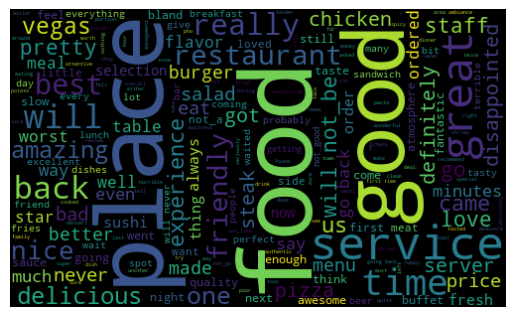

In [10]:
# Combine all messages into a single string
all_messages = ' '.join(data['Review'])

# Create a WordCloud object with the desired settings
wordCloud = WordCloud(width=500, height=300, random_state=20, max_font_size=100).generate(all_messages)

# Display the WordCloud image
plt.imshow(wordCloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [11]:
# Originally will have 1000 row data
# Now allocated 60% data for training, 40% data for testing
X = data.Review
y = data.Liked

#Create training and test sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)    


In [12]:
print(y_train.shape)
print(X_train.shape)

(796,)
(796,)


**Show the heatmap**

In [13]:
# Create heatmap using seaborn
def show_Heatmap(cm):
    plt.figure(figsize=(3,2))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

    # Add labels, title, and ticks
    plt.xlabel('Predicted', fontsize=8)
    plt.ylabel('Actual', fontsize=8)
    plt.title('Confusion Matrix', fontsize=10)
    plt.xticks(ticks=[0.5, 1.5], labels=['Negative', 'Positive'])
    plt.yticks(ticks=[0.5, 1.5], labels=['Negative', 'Positive'])

    plt.show()

### Data Transformation

In [14]:
# Remove common words known as stop words
stop_words = ['english']

# Step 1: Create the document-term matrix using CountVectorizer
count_vectorizer = CountVectorizer(stop_words=stop_words)
X_train_counts = count_vectorizer.fit_transform(X_train)

# Step 2: Compute the TF-IDF values using TfidfTransformer
tfidf_transformer = TfidfTransformer()
X_train_tf = tfidf_transformer.fit_transform(X_train_counts)

# Transform the test data using the already fitted CountVectorizer and TfidfTransformer
X_test_counts = count_vectorizer.transform(X_test)
X_test_tf = tfidf_transformer.transform(X_test_counts)

In [15]:
#This code is to check the IDF value
# all_feature_names = tfidf_vectorizer.get_feature_names_out()

# for word in all_feature_names:
#     indx = tfidf_vectorizer.vocabulary_.get(word)
#     print(f"{word} {tfidf_vectorizer.idf_[indx]}")


## Model Implementation

### Model Training and Model Testing (Logististic Regression)

In [16]:
# Create a logistic regression object
logr = LogisticRegression()

# Fit the model with training dataset
logr.fit(X_train_tf, y_train)

# Use the trained logistic regression model to make predictions on the test set
log_predictions = logr.predict(X_test_tf)


# Create confusion matrix
cm = confusion_matrix(y_test, log_predictions)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

logr.score(X_test_tf, y_test)

Confusion Matrix:
[[79 16]
 [30 74]]


0.7688442211055276

In [17]:
print(X_test.head())

925    i could barely stomach the meal but did not_co...
525    similarly the delivery man did not_say a word ...
567                                   food was delicious
657    that just screams legit in my booksomethats al...
633      highquality chicken on the chicken caesar salad
Name: Review, dtype: object


In [18]:
print(y_test.head())

925    0
525    0
567    1
657    1
633    1
Name: Liked, dtype: int64


Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.83      0.77        95
           1       0.82      0.71      0.76       104

    accuracy                           0.77       199
   macro avg       0.77      0.77      0.77       199
weighted avg       0.78      0.77      0.77       199

Accuracy: 76.88442211055276


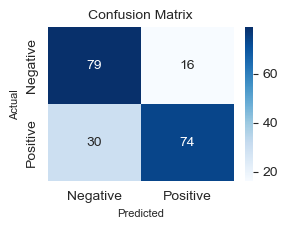

In [19]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, log_predictions))

# Calculate the accuracy of the model
accuracy = (accuracy_score(y_test, log_predictions)*100)
print("Accuracy:", accuracy)

# Create heatmap using seaborn
show_Heatmap(cm)

### Model Tuning for logistics regression

C:\Users\kelvi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        95
           1       0.87      0.75      0.80       104

    accuracy                           0.81       199
   macro avg       0.81      0.81      0.81       199
weighted avg       0.82      0.81      0.81       199

Best Parameters: {'C': 100, 'dual': False, 'penalty': 'l2', 'solver': 'saga'}
LR Accuracy Score ->  80.90452261306532
Balanced Accuracy Score ->  81.1842105263158


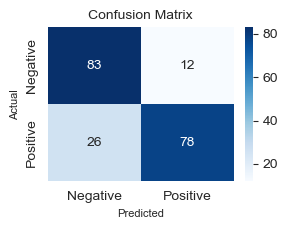

Confusion Matrix:
[[83 12]
 [26 78]] 



In [20]:
# Define the hyperparameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'dual': [False],
    
}

# Perform grid search cross-validation
grid_search = GridSearchCV(logr, param_grid, cv=6, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_tf, y_train)
# Get the best parameters
best_params = grid_search.best_params_

# Use the best model from grid search
best_model = grid_search.best_estimator_

# Make predictions on the test set
predictions = best_model.predict(X_test_tf)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, predictions))

# Create confusion matrix
cm = confusion_matrix(y_test, predictions)

# Print the best parameters
print("Best Parameters:", best_params)
print("LR Accuracy Score -> ", accuracy_score(predictions, y_test) * 100)
print("Balanced Accuracy Score -> ", balanced_accuracy_score(y_test, predictions)  * 100)

show_Heatmap(cm)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm, "\n")

### Model Training and Model Testing (Naive Bayes)

In [21]:
# Create a MultinomialNB object
nb = MultinomialNB() 

# Fit the MultinomialNB model to the 'X_train' and 'y_train' variables
nb.fit(X_train_tf, y_train)

predictions = nb.predict(X_test_tf)
# Print the confusion matrix 
print(confusion_matrix(y_test,predictions))

[[78 17]
 [21 83]]


In [22]:
# Print the classification report
print("Classification Report for MultinomialNB classifier:")
print(classification_report(y_test,predictions))

Classification Report for MultinomialNB classifier:
              precision    recall  f1-score   support

           0       0.79      0.82      0.80        95
           1       0.83      0.80      0.81       104

    accuracy                           0.81       199
   macro avg       0.81      0.81      0.81       199
weighted avg       0.81      0.81      0.81       199



In [23]:
#set classifier = multi nb
classifier = MultinomialNB()
classifier.fit(X_train_tf, y_train)
y_pred = classifier.predict(X_test_tf)

#get the accuracy, precision score
score1 = accuracy_score(y_test,y_pred)
score2 = precision_score(y_test,y_pred)
score3= recall_score(y_test,y_pred)
print("Accuracy score is: {}%".format(round(score1*100,2)))
print("Precision score is: {}".format(round(score2,2)))
print("Recall score is: {}".format(round(score3,4)))

Accuracy score is: 80.9%
Precision score is: 0.83
Recall score is: 0.7981


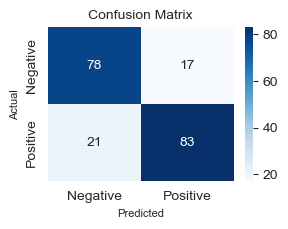

In [24]:
cm = confusion_matrix(y_test, y_pred)
# print the heatmap
show_Heatmap(cm)


### Model Tunning (Naive Bayes)

In [25]:
best_accuracy = 0.0
alpha_val = 0.0

# Loop through different alpha values from 0.1 to 1.0 with a step of 0.1
for i in np.arange(0.1, 1.1, 0.1):
    # Create a new MultinomialNB classifier with the current alpha value
    temp_classifier = MultinomialNB(alpha=i)
    
    # Fit the classifier on the training data
    temp_classifier.fit(X_train_tf, y_train)
    
    # Make predictions on the test set
    test_y_pred = temp_classifier.predict(X_test_tf)
    
    # Calculate the accuracy of the model
    score = accuracy_score(y_test, test_y_pred)
    
    # Check if the current accuracy is better than the previous best accuracy
    if score > best_accuracy:
        best_accuracy = score
        alpha_val = i

# Print the best accuracy and corresponding alpha value
print('The best accuracy is {}% with alpha value as {}'.format(round(best_accuracy * 100, 2), round(alpha_val, 1)))

# Set the classifier to the best MultinomialNB classifier found during tuning
classifier = MultinomialNB(alpha=alpha_val)
classifier.fit(X_train_tf, y_train)

The best accuracy is 82.41% with alpha value as 0.4


MultinomialNB(alpha=0.4)

Classification Report for the best MultinomialNB classifier:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        95
           1       0.85      0.81      0.83       104

    accuracy                           0.82       199
   macro avg       0.82      0.82      0.82       199
weighted avg       0.83      0.82      0.82       199

NB Accuracy Score -> 82.41206030150754
Balanced Accuracy Score ->  82.48987854251013


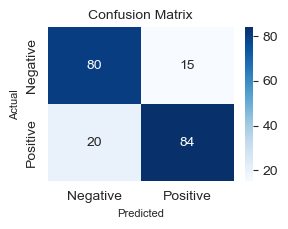

In [26]:
# Create a new MultinomialNB classifier with the best alpha value
best_classifier = MultinomialNB(alpha=alpha_val)

# Fit the best classifier on the training data
best_classifier.fit(X_train_tf, y_train)

# Make predictions on the test set
y_pred = best_classifier.predict(X_test_tf)

# Generate the classification report
class_report = classification_report(y_test, y_pred)

# Print the classification report
print("Classification Report for the best MultinomialNB classifier:")
print(class_report)


print("NB Accuracy Score ->",accuracy_score(y_test,y_pred) * 100)
print("Balanced Accuracy Score -> ",balanced_accuracy_score(y_test,y_pred) * 100)

cm_nb = confusion_matrix(y_test, y_pred)
# Create heatmap using seaborn
show_Heatmap(cm_nb)

### Model Training and Model Testing (SVM)

In [27]:
classifier = SVC(kernel='linear')
classifier.fit(X_train_tf, y_train)
y_pred = classifier.predict(X_test_tf)
print("SVM Accuracy Score ->",accuracy_score(y_test,y_pred) * 100)
print("Balanced Accuracy Score -> ",balanced_accuracy_score(y_test,y_pred) * 100)

SVM Accuracy Score -> 78.89447236180904
Balanced Accuracy Score ->  79.21558704453442


In [28]:
print("Classification Report:")
print(classification_report(y_test,y_pred))
print("SVM Accuracy Score ->",accuracy_score(y_test,y_pred) * 100)
print("Confusion Matrix:")
print(confusion_matrix (y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.86      0.80        95
           1       0.85      0.72      0.78       104

    accuracy                           0.79       199
   macro avg       0.80      0.79      0.79       199
weighted avg       0.80      0.79      0.79       199

SVM Accuracy Score -> 78.89447236180904
Confusion Matrix:
[[82 13]
 [29 75]]


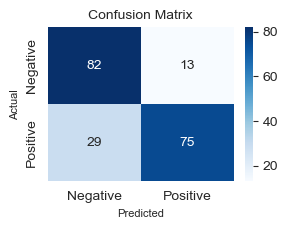

In [29]:
cm_svm = confusion_matrix(y_test, y_pred)
# Create heatmap using seaborn
show_Heatmap(cm_svm)

In [30]:
# Hyperparameter tuning using Grid Search
# Param grid with parameter of C = [0.1, 1.0, 10.0] and kernel = ['linear', 'poly', 'rbf', 'sigmoid'] and 
# Define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1.0,10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

best_accuracy = 0.0
best_params = {}

for C_value in param_grid['C']:
    for kernel_value in param_grid['kernel']:
        # Train the SVM with the current hyperparameters
        SVM = SVC(C=C_value, kernel=kernel_value, gamma='auto', random_state=42, probability=True, class_weight='balanced')
        SVM.fit(X_train_tf, y_train)
        
        # Make predictions
        predictions_SVM = SVM.predict(X_test_tf)
        
        # Calculate accuracy
        current_accuracy = accuracy_score(predictions_SVM, y_test)
        
        # Check if the current model has higher accuracy
        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy
            best_params = {'C': C_value, 'kernel': kernel_value}

# Print the best hyperparameters
print("Best hyperparameters found =", best_params)
print("Accuracy of the best hyperparameters =", best_accuracy)



Best hyperparameters found = {'C': 10, 'kernel': 'linear'}
Accuracy of the best hyperparameters = 0.8090452261306532


### Model Tunning (SVM)

In [31]:
# Retrain SVM model with best hyperparameters
SVM = SVC(C=best_params['C'], kernel=best_params['kernel'], gamma='auto')
SVM.fit(X_train_tf, y_train)
predictions_SVM = SVM.predict(X_test_tf)
print("SVM Accuracy Score -> ", accuracy_score(y_test,predictions_SVM) * 100)
balanced_acc = balanced_accuracy_score(y_test, predictions_SVM)
print("Balanced Accuracy Score -> ", balanced_acc* 100)

# Evaluate the performance of the classifier
print("Classification Report: ")
print(classification_report(y_test, predictions_SVM))
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_SVM))

SVM Accuracy Score ->  80.90452261306532
Balanced Accuracy Score ->  81.09311740890688
Classification Report: 
              precision    recall  f1-score   support

           0       0.77      0.85      0.81        95
           1       0.85      0.77      0.81       104

    accuracy                           0.81       199
   macro avg       0.81      0.81      0.81       199
weighted avg       0.81      0.81      0.81       199

Confusion Matrix:
[[81 14]
 [24 80]]


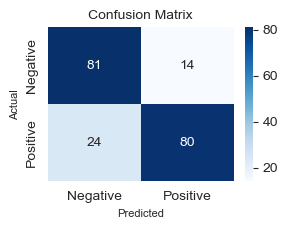

In [32]:
cm_svm = confusion_matrix(y_test, predictions_SVM)
# Create heatmap using seaborn
show_Heatmap(cm_svm)

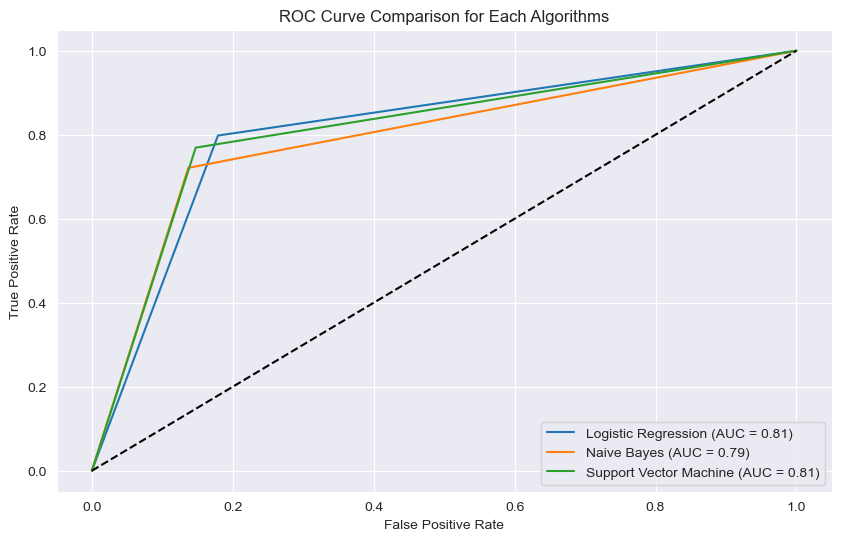

In [33]:
fpr_model1, tpr_model1, _ = roc_curve(y_test, predictions)
fpr_model2, tpr_model2, _ = roc_curve(y_test, y_pred)
fpr_model3, tpr_model3, _ = roc_curve(y_test, predictions_SVM)

auc_model1 = roc_auc_score(y_test, predictions)
auc_model2 = roc_auc_score(y_test, y_pred)
auc_model3 = roc_auc_score(y_test, predictions_SVM)

# Step 4: Plot the ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_model1, tpr_model1, label='Logistic Regression (AUC = {:.2f})'.format(auc_model1))
plt.plot(fpr_model2, tpr_model2, label='Naive Bayes (AUC = {:.2f})'.format(auc_model2))
plt.plot(fpr_model3, tpr_model3, label='Support Vector Machine (AUC = {:.2f})'.format(auc_model3))

# Step 5: Add labels, legend, and other visual elements
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison for Each Algorithms')
plt.legend(loc='lower right')
plt.grid(True)

# Step 6: Show the plot
plt.show()

# Tweets Cleaning

In [ ]:
# Load the Excel file into a pandas DataFrame
data = pd.read_excel('yelp_reviews.xlsx')

# Print the first few rows of the DataFrame
print(data.head())

                                              Review  Rating  Sentiment
0  My girlfriend and I were wondering around SOHO...     4.4          1
1  My waiter Jonathan was the best waiter ever. T...     4.5          1
2  This is the best dining experience in London. ...     5.0          1
3  This is a chain of restaurants located in cent...     5.0          1
4  This is hands down, my absolute favorite resta...     5.0          1


In [35]:
# Function to clean the review text


# Apply the cleaning function to the review column
data['Review'] = data['Review'].apply(clean_text)

data = data.drop_duplicates()
data = data.drop('Rating', axis=1)
data = data.dropna()

# Print the first few rows of the DataFrame
print(data.head())

                                              Review  Sentiment
0  my girlfriend and i were wondering around soho...          1
1  my waiter jonathan was the best waiter ever th...          1
2  this is the best dining experience in london t...          1
3  this is a chain of restaurants located in cent...          1
4  this is hands down my absolute favorite restau...          1


In [36]:
print(len(data))

448


In [37]:
X_tweets = data.Review
y_tweets = data.Sentiment

## Data Transformation

In [38]:
# Transform the test data using the already fitted CountVectorizer and TfidfTransformer
X_crawl_counts = count_vectorizer.transform(X_tweets)

X_crawl_tf = tfidf_transformer.transform(X_crawl_counts)


## Model Implementation (Logistic Regression)

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.62      0.39        42
           1       0.96      0.84      0.89       406

    accuracy                           0.82       448
   macro avg       0.62      0.73      0.64       448
weighted avg       0.89      0.82      0.85       448

LR Accuracy Score -> 81.91964285714286
Balanced Accuracy Score ->  72.94745484400657


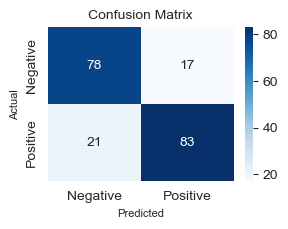

Confusion Matrix:
[[ 26  16]
 [ 65 341]] 



In [39]:
# Make predictions on the test set
predictions_LR = best_model.predict(X_crawl_tf)

# Print the classification report
print("Classification Report:")
print(classification_report(y_tweets, predictions_LR))

print("LR Accuracy Score ->",accuracy_score(y_tweets,predictions_LR) * 100)
print("Balanced Accuracy Score -> ",balanced_accuracy_score(y_tweets,predictions_LR) * 100)
# Create heatmap using seaborn
show_Heatmap(cm) 

# Create confusion matrix
cm = confusion_matrix(y_tweets, predictions_LR)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm, "\n")

## Model Implementation (Naive Bayes)

[[ 28  14]
 [ 90 316]]
Classification Report for the best MultinomialNB classifier:
              precision    recall  f1-score   support

           0       0.24      0.67      0.35        42
           1       0.96      0.78      0.86       406

    accuracy                           0.77       448
   macro avg       0.60      0.72      0.60       448
weighted avg       0.89      0.77      0.81       448

NB Accuracy Score -> 76.78571428571429
Balanced Accuracy Score ->  72.2495894909688


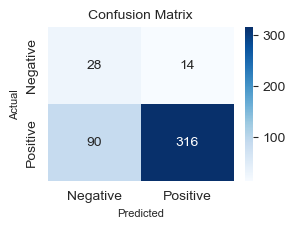

In [40]:

# Make predictions on the test set
predictions_NB = best_classifier.predict(X_crawl_tf)

# Generate the classification report
class_report = classification_report(y_tweets, predictions_NB)

# Confusion Matrix
model_implement_cm_NB = confusion_matrix(y_tweets, predictions_NB)
print(model_implement_cm_NB)
# Print the classification report
print("Classification Report for the best MultinomialNB classifier:")
print(class_report)
print("NB Accuracy Score ->",accuracy_score(y_tweets,predictions_NB) * 100)
print("Balanced Accuracy Score -> ",balanced_accuracy_score(y_tweets,predictions_NB) * 100)
show_Heatmap(model_implement_cm_NB)

## Model Implementation (SVM)

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.62      0.42        42
           1       0.96      0.86      0.91       406

    accuracy                           0.84       448
   macro avg       0.64      0.74      0.66       448
weighted avg       0.90      0.84      0.86       448

SVM Accuracy Score -> 83.92857142857143
Balanced Accuracy Score ->  74.05582922824301
Confusion Matrix -> 
 [[ 26  16]
 [ 56 350]]


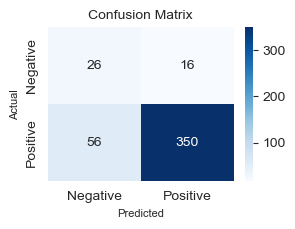

In [41]:
predictions_SVM = SVM.predict(X_crawl_tf)
model_implement_cm_SVM = confusion_matrix(y_tweets, predictions_SVM)

# Print the classification report
print("Classification Report:")
print(classification_report(y_tweets, predictions_SVM))
print("SVM Accuracy Score ->",accuracy_score(y_tweets,predictions_SVM) * 100)
print("Balanced Accuracy Score -> ",balanced_accuracy_score(y_tweets,predictions_SVM) * 100)
print("Confusion Matrix -> \n",model_implement_cm_SVM)
show_Heatmap(model_implement_cm_SVM)


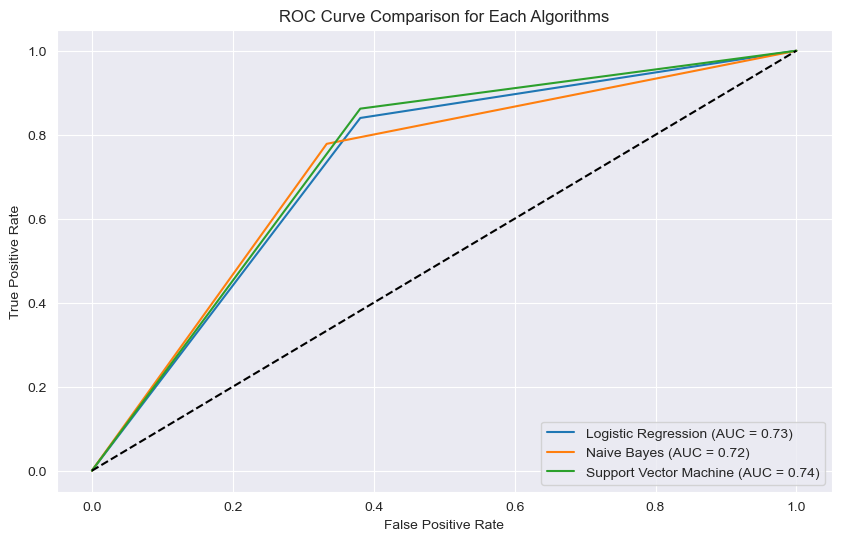

In [42]:
fpr_model1, tpr_model1, _ = roc_curve(y_tweets, predictions_LR)
fpr_model2, tpr_model2, _ = roc_curve(y_tweets, predictions_NB)
fpr_model3, tpr_model3, _ = roc_curve(y_tweets, predictions_SVM)

auc_model1 = roc_auc_score(y_tweets, predictions_LR)
auc_model2 = roc_auc_score(y_tweets, predictions_NB)
auc_model3 = roc_auc_score(y_tweets, predictions_SVM)

# Step 4: Plot the ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_model1, tpr_model1, label='Logistic Regression (AUC = {:.2f})'.format(auc_model1))
plt.plot(fpr_model2, tpr_model2, label='Naive Bayes (AUC = {:.2f})'.format(auc_model2))
plt.plot(fpr_model3, tpr_model3, label='Support Vector Machine (AUC = {:.2f})'.format(auc_model3))

# Step 5: Add labels, legend, and other visual elements
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison for Each Algorithms')
plt.legend(loc='lower right')
plt.grid(True)

# Step 6: Show the plot
plt.show()

# Analysing the Data

In [43]:
import tkinter as tk
from tkinter import ttk
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Function to predict sentiment of a review
def predict_sentiment(sample_review):
    sample_review = clean_text(sample_review)
    sample_review_words = sample_review.split()
    sample_review_words = [word for word in sample_review_words if not word in set(stopwords.words('english'))]
    port = PorterStemmer()
    final_review = [port.stem(word) for word in sample_review_words]
    final_review = ' '.join(final_review)
    temp1 = count_vectorizer.transform([final_review]).toarray()
    temp = tfidf_transformer.transform(temp1)
    return classifier.predict(temp)

# Function to perform sentiment analysis
def analyze_sentiment(event):
    review_text = review_input.get()
    if not review_text:
        sentiment_result.config(text="Please enter a review text!")
        return

    # Check if the review text has meaning
    if len(review_text) <= 2:
        sentiment_result.config(text="The review text must be meaningful!")
        return

    # Display the result
    color = "green" if predict_sentiment(review_text) else "red"
    text = "Positive Review" if color == "green" else "Negative Review"
    sentiment_result.config(text="Sentiment: {}!".format(text), foreground=color)

# Create the GUI
root = tk.Tk()
root.title("Sentiment Analysis")

frame = ttk.Frame(root)
frame.pack(pady=10)

# Input for entering the review text
review_input = ttk.Entry(frame, width=50)
review_input.bind("<Return>", analyze_sentiment)
review_input.pack(pady=15)

# Button to analyze sentiment
analyze_button = ttk.Button(frame, text="Analyze Sentiment", command=analyze_sentiment)
analyze_button.pack(pady=40)

# Label to display the sentiment result
sentiment_result = ttk.Label(frame, text="", font=("Helvetica", 18))
sentiment_result.pack(pady=10)

root.mainloop()


## Crawl Data

In [ ]:
def scrape_data(url):
    r = requests.get(url)
    soup = BeautifulSoup(r.text, 'html.parser')

    # Scrape reviews
    divs_reviews = soup.findAll(class_='comment__09f24__D0cxf')
    reviews = [result.find('span').text for result in divs_reviews]

    # Scrape ratings
    divs_ratings = soup.findAll('div', class_='five-stars__09f24__mBKym')
    ratings = []
    for result in divs_ratings:
        try:
            rating = float(result['aria-label'].split()[0])
            ratings.append(rating)
        except ValueError:
            pass  # Ignore invalid ratings (e.g., '(no star rating)')

    return reviews, ratings

base_url = 'https://www.yelp.com/biz/la-crosta-pizza-bar-walnut-creek?osq=Restaurants'
start = 0
data_all_pages = []

while True:
    page_url = f'{base_url}&start={start}'
    reviews, ratings = scrape_data(page_url)

    if not reviews:  # If there are no reviews on the page, we reached the end.
        break

    data_all_pages.extend(zip(reviews, ratings))
    start += 10  # Yelp typically shows 20 reviews per page

    print(f"Scraped {len(reviews)} reviews and {len(ratings)} ratings from page {start//20}...")
    time.sleep(3)  # Adding a delay to avoid overloading the server

# Print all the reviews and ratings
for review, rating in data_all_pages:
    print(f"Review: {review}, Rating: {rating}")
